In [2]:
# ============================================================
# PHASE 2 — NLP MÉDICAL
# Classification de transcriptions médicales
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# Chargement
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/bakagnan/mtsamples-csv/mtsamples.csv


In [3]:
# ============================================================
# ÉTAPE 1 — CHARGEMENT ET APERÇU
# ============================================================
PATH = "/kaggle/input/datasets/bakagnan/mtsamples-csv/mtsamples.csv"
df = pd.read_csv(PATH)

print(f"Shape : {df.shape}")
print(f"\nColonnes : {df.columns.tolist()}")
print(f"\nTypes :\n{df.dtypes}")
display(df.head(3))

Shape : (4999, 6)

Colonnes : ['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']

Types :
Unnamed: 0            int64
description          object
medical_specialty    object
sample_name          object
transcription        object
keywords             object
dtype: object


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."


Nombre de spécialités : 40
Total documents       : 4999

Top 10 spécialités :


,count
medical_specialty,
Surgery,1103
Consult - History and Phy.,516
Cardiovascular / Pulmonary,372
Orthopedic,355
Radiology,273
General Medicine,259
Gastroenterology,230
Neurology,223
SOAP / Chart / Progress Notes,166



Bottom 5 spécialités (peu représentées) :


,count
medical_specialty,
Speech - Language,9
Autopsy,8
Lab Medicine - Pathology,8
Allergy / Immunology,7
Hospice - Palliative Care,6


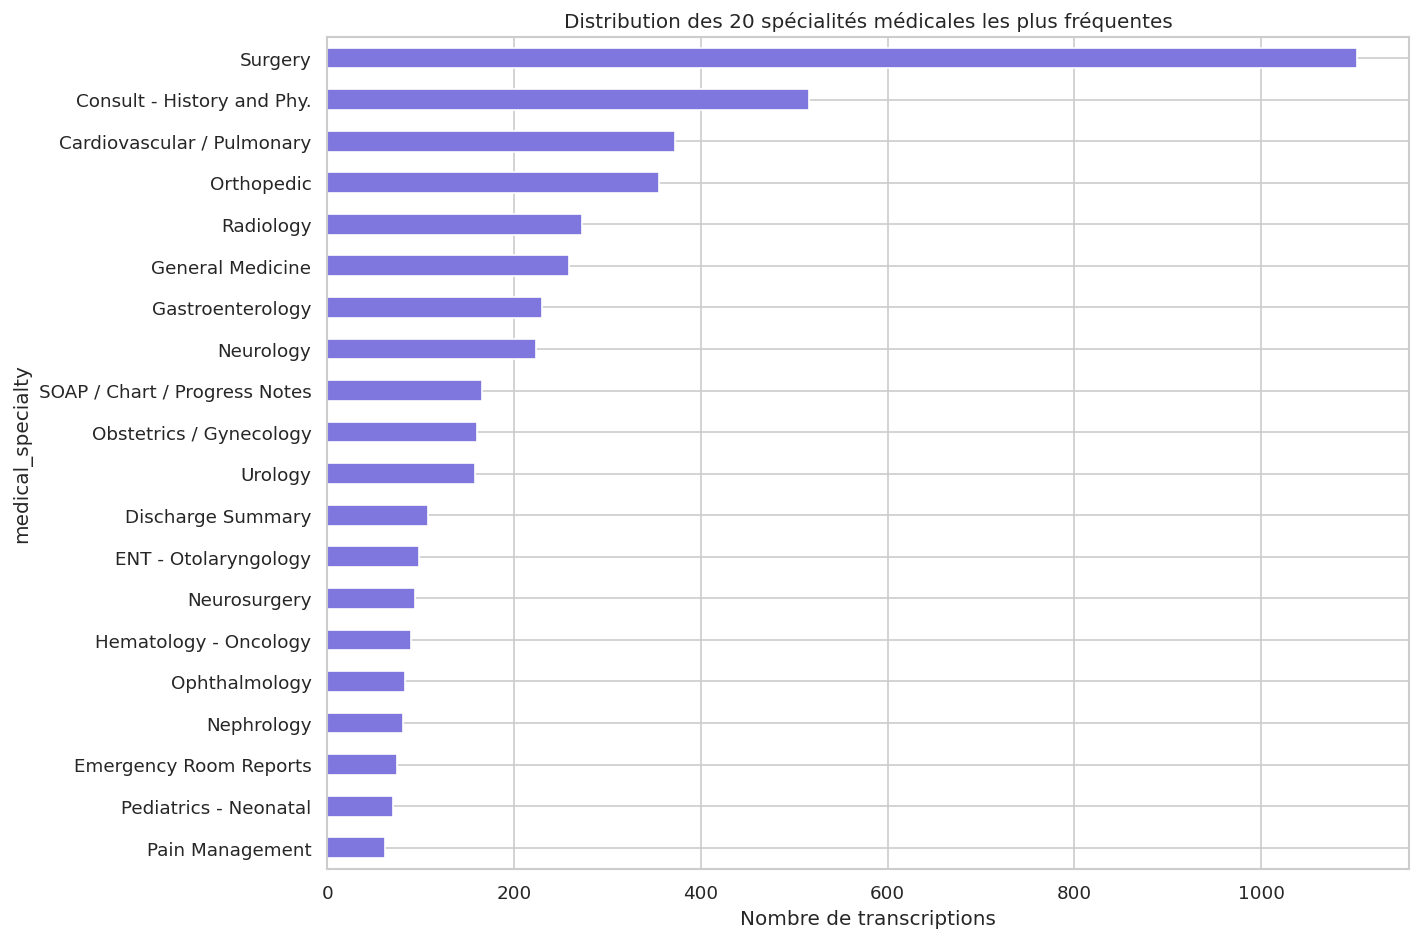

In [4]:
# ============================================================
# ÉTAPE 1 — EXPLORATION DE LA VARIABLE CIBLE
# ============================================================

# Nettoyage basique du nom de la cible
df["medical_specialty"] = df["medical_specialty"].str.strip()

# Distribution des spécialités
specialty_counts = df["medical_specialty"].value_counts()

print(f"Nombre de spécialités : {df['medical_specialty'].nunique()}")
print(f"Total documents       : {len(df)}")
print(f"\nTop 10 spécialités :")
display(specialty_counts.head(10).to_frame())
print(f"\nBottom 5 spécialités (peu représentées) :")
display(specialty_counts.tail(5).to_frame())

# Visualisation
fig, ax = plt.subplots(figsize=(12, 8))
specialty_counts.head(20).plot(
    kind="barh", ax=ax,
    color="#7F77DD", edgecolor="white"
)
ax.set_title("Distribution des 20 spécialités médicales les plus fréquentes")
ax.set_xlabel("Nombre de transcriptions")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# ÉTAPE 1 — FILTRAGE ET NETTOYAGE
# ============================================================

# Garder uniquement les spécialités avec >= 50 documents
min_docs = 50
valid_specialties = specialty_counts[specialty_counts >= min_docs].index
df_filtered = df[df["medical_specialty"].isin(valid_specialties)].copy()

print(f"Avant filtrage  : {len(df)} documents, {df['medical_specialty'].nunique()} spécialités")
print(f"Après filtrage  : {len(df_filtered)} documents, {df_filtered['medical_specialty'].nunique()} spécialités")
print(f"\nSpécialités conservées :")
display(df_filtered["medical_specialty"].value_counts().to_frame())

# Supprimer les lignes sans transcription
df_filtered = df_filtered.dropna(subset=["transcription"])
df_filtered = df_filtered[df_filtered["transcription"].str.strip() != ""]
print(f"\nAprès suppression des textes vides : {len(df_filtered)} documents")

# Variable cible
print(f"\nDistribution finale :")
print(df_filtered["medical_specialty"].value_counts())

Avant filtrage  : 4999 documents, 40 spécialités
Après filtrage  : 4680 documents, 22 spécialités

Spécialités conservées :


,count
medical_specialty,
Surgery,1103
Consult - History and Phy.,516
Cardiovascular / Pulmonary,372
Orthopedic,355
Radiology,273
General Medicine,259
Gastroenterology,230
Neurology,223
SOAP / Chart / Progress Notes,166



Après suppression des textes vides : 4647 documents

Distribution finale :
medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Obstetrics / Gynecology           155
Discharge Summary                 108
ENT - Otolaryngology               96
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Pediatrics - Neonatal              70
Pain Management                    61
Psychiatry / Psychology            53
Office Notes                       50
Name: count, dtype: int64


In [6]:
# ============================================================
# ÉTAPE 1 — NETTOYAGE DU TEXTE
# ============================================================
import re
import nltk
nltk.download("stopwords")
nltk.download("punkt")
from nltk.corpus import stopwords

STOPWORDS_EN = set(stopwords.words("english"))

def clean_text(text):
    """
    Nettoie un texte médical :
    1. Minuscules
    2. Supprime les chiffres et ponctuation
    3. Supprime les espaces multiples
    4. Supprime les stopwords
    """
    if not isinstance(text, str):
        return ""
    # Minuscules
    text = text.lower()
    # Supprimer les caractères spéciaux et chiffres
    text = re.sub(r"[^a-z\s]", " ", text)
    # Supprimer les espaces multiples
    text = re.sub(r"\s+", " ", text).strip()
    # Supprimer les stopwords
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS_EN and len(t) > 2]
    return " ".join(tokens)

# Appliquer le nettoyage
df_filtered["text_clean"] = df_filtered["transcription"].apply(clean_text)

# Vérification
print("Exemple AVANT nettoyage :")
print(df_filtered["transcription"].iloc[0][:300])
print("\nExemple APRÈS nettoyage :")
print(df_filtered["text_clean"].iloc[0][:300])

# Longueur des textes
df_filtered["text_length"] = df_filtered["text_clean"].apply(len)
df_filtered["word_count"]  = df_filtered["text_clean"].apply(lambda x: len(x.split()))

print(f"\nLongueur moyenne des textes : {df_filtered['word_count'].mean():.0f} mots")
print(f"Longueur min                : {df_filtered['word_count'].min()} mots")
print(f"Longueur max                : {df_filtered['word_count'].max()} mots")

[nltk_data] Error loading stopwords: <urlopen error [Errno -3]
[nltk_data]     Temporary failure in name resolution>
[nltk_data] Error loading punkt: <urlopen error [Errno -3] Temporary
[nltk_data]     failure in name resolution>


Exemple AVANT nettoyage :
2-D M-MODE: , ,1.  Left atrial enlargement with left atrial diameter of 4.7 cm.,2.  Normal size right and left ventricle.,3.  Normal LV systolic function with left ventricular ejection fraction of 51%.,4.  Normal LV diastolic function.,5.  No pericardial effusion.,6.  Normal morphology of aortic val

Exemple APRÈS nettoyage :
mode left atrial enlargement left atrial diameter normal size right left ventricle normal systolic function left ventricular ejection fraction normal diastolic function pericardial effusion normal morphology aortic valve mitral valve tricuspid valve pulmonary valve systolic pressure mmhg doppler mil

Longueur moyenne des textes : 264 mots
Longueur min                : 1 mots
Longueur max                : 1274 mots


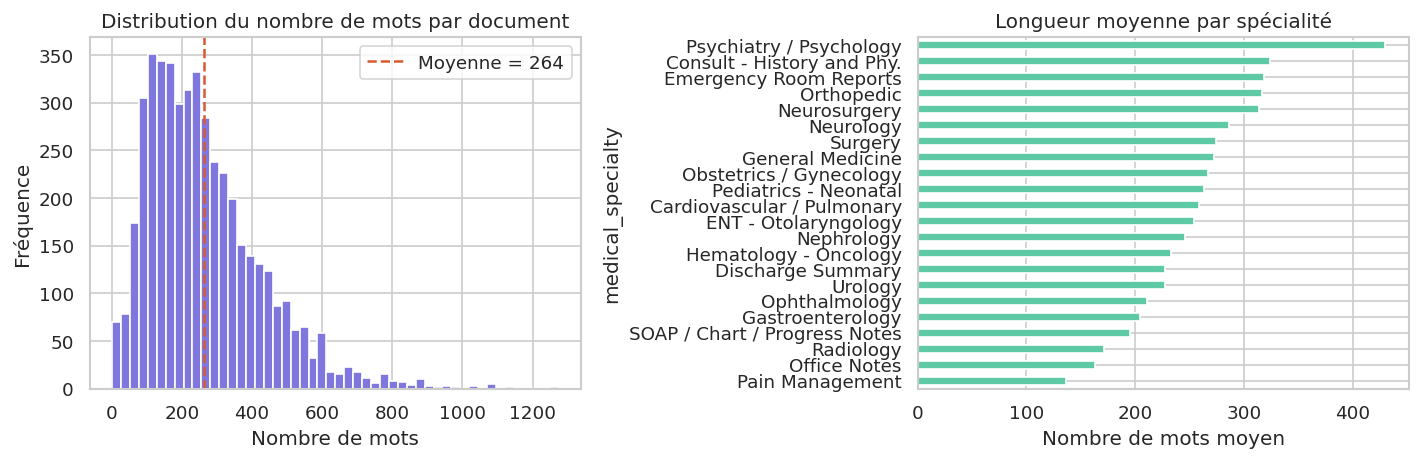


Classes encodées :
   0 → Cardiovascular / Pulmonary
   1 → Consult - History and Phy.
   2 → Discharge Summary
   3 → ENT - Otolaryngology
   4 → Emergency Room Reports
   5 → Gastroenterology
   6 → General Medicine
   7 → Hematology - Oncology
   8 → Nephrology
   9 → Neurology
  10 → Neurosurgery
  11 → Obstetrics / Gynecology
  12 → Office Notes
  13 → Ophthalmology
  14 → Orthopedic
  15 → Pain Management
  16 → Pediatrics - Neonatal
  17 → Psychiatry / Psychology
  18 → Radiology
  19 → SOAP / Chart / Progress Notes
  20 → Surgery
  21 → Urology

Nombre de classes : 22


In [7]:
# ============================================================
# ÉTAPE 1 — VISUALISATION + ENCODAGE CIBLE
# ============================================================
from sklearn.preprocessing import LabelEncoder

# Distribution des longueurs
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_filtered["word_count"], bins=50,
             color="#7F77DD", edgecolor="white")
axes[0].set_title("Distribution du nombre de mots par document")
axes[0].set_xlabel("Nombre de mots")
axes[0].set_ylabel("Fréquence")
axes[0].axvline(df_filtered["word_count"].mean(),
                color="#D85A30", linestyle="--",
                label=f"Moyenne = {df_filtered['word_count'].mean():.0f}")
axes[0].legend()

# Longueur moyenne par spécialité
avg_length = df_filtered.groupby("medical_specialty")["word_count"].mean().sort_values()
avg_length.plot(kind="barh", ax=axes[1], color="#5DCAA5", edgecolor="white")
axes[1].set_title("Longueur moyenne par spécialité")
axes[1].set_xlabel("Nombre de mots moyen")

plt.tight_layout()
plt.show()

# Encodage de la variable cible
le = LabelEncoder()
df_filtered["label"] = le.fit_transform(df_filtered["medical_specialty"])

print(f"\nClasses encodées :")
for i, cls in enumerate(le.classes_):
    print(f"  {i:2d} → {cls}")

print(f"\nNombre de classes : {len(le.classes_)}")

In [8]:
# ============================================================
# ÉTAPE 2 — SPLIT + VECTORISATION TF-IDF
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Filtrer les documents trop courts
df_filtered = df_filtered[df_filtered["word_count"] >= 10].copy()
print(f"Documents après filtrage (>= 10 mots) : {len(df_filtered)}")

# Split stratifié
X = df_filtered["text_clean"]
y = df_filtered["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=12,
    stratify=y
)
print(f"\nTrain : {len(X_train)} documents")
print(f"Test  : {len(X_test)} documents")

# TF-IDF
# max_features = 10000 → garder les 10 000 mots les plus importants
# ngram_range  = (1,2) → unigrammes ET bigrammes
#                ex: "heart failure" est plus informatif que "heart" seul
# sublinear_tf = True  → log(tf) au lieu de tf → réduit l'impact des mots très fréquents
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3          # ignorer les mots qui apparaissent dans moins de 3 documents
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"\nMatrice TF-IDF train : {X_train_tfidf.shape}")
print(f"Matrice TF-IDF test  : {X_test_tfidf.shape}")
print(f"→ {X_train_tfidf.shape[0]} documents × {X_train_tfidf.shape[1]} features")
print(f"\nDensité de la matrice : {X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.4f}")
print(f"→ La matrice est très sparse (creuse) — c'est normal en NLP")

Documents après filtrage (>= 10 mots) : 4610

Train : 3688 documents
Test  : 922 documents

Matrice TF-IDF train : (3688, 10000)
Matrice TF-IDF test  : (922, 10000)
→ 3688 documents × 10000 features

Densité de la matrice : 0.0212
→ La matrice est très sparse (creuse) — c'est normal en NLP


In [9]:
# ============================================================
# ÉTAPE 2 — MODÈLES CLASSIQUES SUR TF-IDF
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, f1_score
import joblib, os

# Définition des modèles
models_tfidf = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
        C=1.0
    ),
    "LinearSVC": LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=2000,
        C=1.0
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
}

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "f1_macro"  : "f1_macro",
    "f1_weighted": "f1_weighted",
    "accuracy"  : "accuracy",
}

cv_results_tfidf = {}
print("Cross-validation TF-IDF en cours...\n")
for name, model in models_tfidf.items():
    print(f"  Fitting {name}...", end=" ")
    scores = cross_validate(
        model,
        X_train_tfidf, y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    cv_results_tfidf[name] = scores
    print(f"F1-macro = {scores['test_f1_macro'].mean():.4f} "
          f"(+/- {scores['test_f1_macro'].std():.4f})")

# Tableau comparatif
rows = []
for name, scores in cv_results_tfidf.items():
    rows.append({
        "Modèle"      : name,
        "F1-macro"    : f"{scores['test_f1_macro'].mean():.4f} ± {scores['test_f1_macro'].std():.4f}",
        "F1-weighted" : f"{scores['test_f1_weighted'].mean():.4f} ± {scores['test_f1_weighted'].std():.4f}",
        "Accuracy"    : f"{scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}",
    })

results_df = pd.DataFrame(rows).set_index("Modèle")
print("\nComparaison des modèles TF-IDF (5 folds) :")
display(results_df)

Cross-validation TF-IDF en cours...

  Fitting LogisticRegression... F1-macro = 0.3729 (+/- 0.0061)
  Fitting LinearSVC... F1-macro = 0.2228 (+/- 0.0203)
  Fitting RandomForest... F1-macro = 0.1401 (+/- 0.0086)

Comparaison des modèles TF-IDF (5 folds) :


,F1-macro,F1-weighted,Accuracy
Modèle,,,
LogisticRegression,0.3729 ± 0.0061,0.3175 ± 0.0087,0.3444 ± 0.0069
LinearSVC,0.2228 ± 0.0203,0.1925 ± 0.0130,0.1982 ± 0.0126
RandomForest,0.1401 ± 0.0086,0.1695 ± 0.0075,0.1779 ± 0.0082


In [10]:
# ============================================================
# ÉTAPE 2 — ÉVALUATION FINALE SUR TEST SET
# ============================================================
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, ConfusionMatrixDisplay
)

# Entraîner le meilleur modèle sur tout le train
best_tfidf_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
    C=1.0
)
best_tfidf_model.fit(X_train_tfidf, y_train)

# Prédictions sur le test set
y_pred_tfidf = best_tfidf_model.predict(X_test_tfidf)

# Métriques
f1_macro   = f1_score(y_test, y_pred_tfidf, average="macro")
f1_weighted = f1_score(y_test, y_pred_tfidf, average="weighted")
accuracy   = (y_pred_tfidf == y_test).mean()

print(f"Résultats TF-IDF + LogisticRegression (test set) :")
print(f"  F1-macro    : {f1_macro:.4f}")
print(f"  F1-weighted : {f1_weighted:.4f}")
print(f"  Accuracy    : {accuracy:.4f}")

# Rapport détaillé par classe
print(f"\nRapport détaillé par spécialité :")
print(classification_report(
    y_test, y_pred_tfidf,
    target_names=le.classes_,
    digits=3
))

Résultats TF-IDF + LogisticRegression (test set) :
  F1-macro    : 0.3860
  F1-weighted : 0.3059
  Accuracy    : 0.3460

Rapport détaillé par spécialité :
                               precision    recall  f1-score   support

   Cardiovascular / Pulmonary      0.367     0.446     0.402        74
   Consult - History and Phy.      0.263     0.147     0.189       102
            Discharge Summary      0.361     0.591     0.448        22
         ENT - Otolaryngology      0.371     0.684     0.481        19
       Emergency Room Reports      0.207     0.400     0.273        15
             Gastroenterology      0.368     0.477     0.416        44
             General Medicine      0.192     0.098     0.130        51
        Hematology - Oncology      0.037     0.056     0.044        18
                   Nephrology      0.241     0.438     0.311        16
                    Neurology      0.309     0.378     0.340        45
                 Neurosurgery      0.292     0.737     0.418   

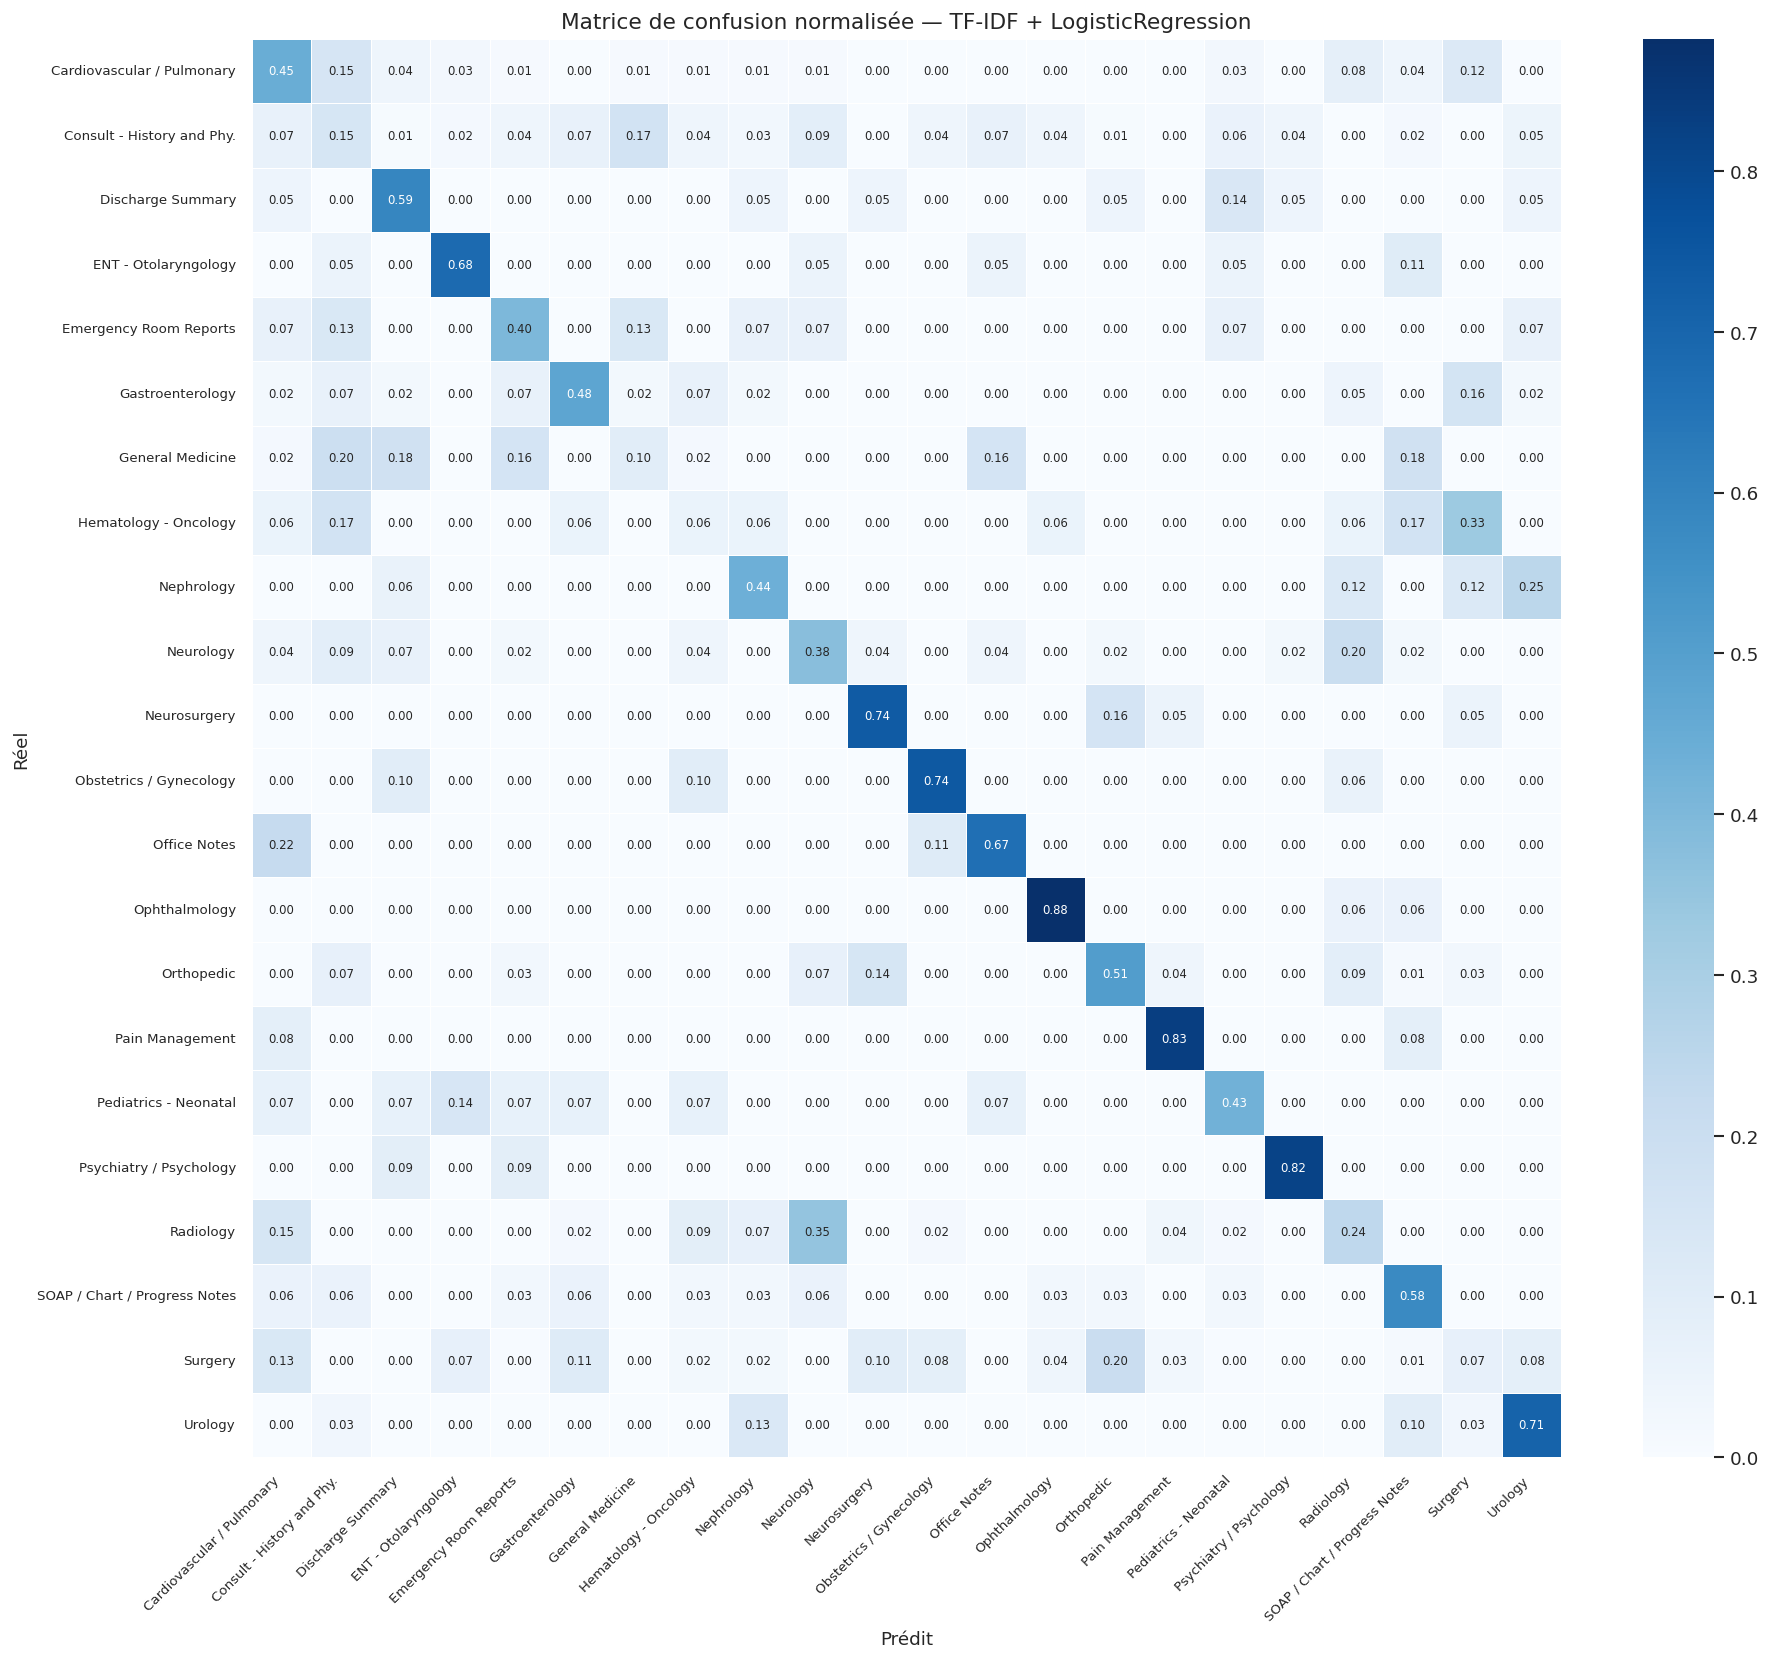


Top 10 confusions (classes réelles vs prédites) :


,Réel,Prédit,Taux
26,Radiology,Neurology,0.352
15,Hematology - Oncology,Surgery,0.333
18,Nephrology,Urology,0.250
21,Office Notes,Cardiovascular / Pulmonary,0.222
29,Surgery,Orthopedic,0.204
19,Neurology,Radiology,0.200
8,General Medicine,Consult - History and Phy.,0.196
9,General Medicine,Discharge Summary,0.176
12,General Medicine,SOAP / Chart / Progress Notes,0.176
13,Hematology - Oncology,Consult - History and Phy.,0.167


In [11]:
# ============================================================
# ÉTAPE 2 — MATRICE DE CONFUSION
# ============================================================
import seaborn as sns

# Matrice de confusion normalisée
cm = confusion_matrix(y_test, y_pred_tfidf, normalize="true")

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    ax=ax,
    linewidths=0.3,
    annot_kws={"size": 7}
)
ax.set_title("Matrice de confusion normalisée — TF-IDF + LogisticRegression",
             fontsize=13)
ax.set_xlabel("Prédit", fontsize=11)
ax.set_ylabel("Réel", fontsize=11)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Top confusions
print("\nTop 10 confusions (classes réelles vs prédites) :")
confusion_pairs = []
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        if i != j and cm[i, j] > 0.1:
            confusion_pairs.append({
                "Réel"   : le.classes_[i],
                "Prédit" : le.classes_[j],
                "Taux"   : round(cm[i, j], 3)
            })

confusion_df = pd.DataFrame(confusion_pairs).sort_values(
    "Taux", ascending=False
).head(10)
display(confusion_df)

In [12]:
# ============================================================
# ÉTAPE 3 — WORD2VEC EMBEDDINGS
# ============================================================
from gensim.models import Word2Vec
import numpy as np

# Word2Vec travaille sur des listes de tokens (pas sur du texte brut)
# On tokenise chaque document
print("Tokenisation des documents...")
tokenized_docs = [text.split() for text in df_filtered["text_clean"]]

print(f"Nombre de documents : {len(tokenized_docs)}")
print(f"Exemple (10 premiers tokens) : {tokenized_docs[0][:10]}")

# Entraînement du modèle Word2Vec
# vector_size = 100  → chaque mot = vecteur de 100 dimensions
# window      = 5    → contexte de 5 mots autour du mot cible
# min_count   = 3    → ignorer les mots qui apparaissent < 3 fois
# workers     = 4    → parallélisation
# sg          = 1    → Skip-gram (prédit le contexte à partir du mot)
#                      meilleur sur données médicales spécialisées
print("\nEntraînement Word2Vec...")
w2v_model = Word2Vec(
    sentences=tokenized_docs,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4,
    sg=1,
    epochs=10,
    seed=42
)

print(f"Vocabulaire appris : {len(w2v_model.wv)} mots")
print(f"Dimension des vecteurs : {w2v_model.vector_size}")

# Test des similarités sémantiques
print("\nTest des relations sémantiques :")
test_words = ["cardiac", "surgery", "patient", "pain"]
for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        print(f"\n  '{word}' → mots proches :")
        for w, score in similar:
            print(f"    {w:30s} similarité = {score:.4f}")

Tokenisation des documents...
Nombre de documents : 4610
Exemple (10 premiers tokens) : ['mode', 'left', 'atrial', 'enlargement', 'left', 'atrial', 'diameter', 'normal', 'size', 'right']

Entraînement Word2Vec...
Vocabulaire appris : 14754 mots
Dimension des vecteurs : 100

Test des relations sémantiques :

  'cardiac' → mots proches :
    enzyme                         similarité = 0.6617
    heart                          similarité = 0.6331
    catheterization                similarité = 0.6171
    tachycardic                    similarité = 0.6167
    siemens                        similarité = 0.5942

  'surgery' → mots proches :
    sacrocolpopexy                 similarité = 0.6313
    mua                            similarité = 0.6282
    reconstructive                 similarité = 0.6232
    surgeries                      similarité = 0.6144
    femoropopliteal                similarité = 0.6122

  'patient' → mots proches :
    hypersensitivity               similarité = 0.71

In [13]:
# ============================================================
# ÉTAPE 3 — VECTORISATION DOCUMENTS AVEC WORD2VEC
# ============================================================
# Word2Vec donne un vecteur PAR MOT
# Pour classifier un document, on fait la MOYENNE
# des vecteurs de tous ses mots
# → "document embedding" par moyenne

def document_embedding(text, model, vector_size=100):
    """
    Convertit un document en vecteur en moyennant
    les vecteurs Word2Vec de chaque mot.
    """
    tokens = text.split()
    # Garder uniquement les mots dans le vocabulaire
    vectors = [
        model.wv[word]
        for word in tokens
        if word in model.wv
    ]
    if len(vectors) == 0:
        # Document vide après filtrage → vecteur nul
        return np.zeros(vector_size)
    # Moyenne des vecteurs de mots
    return np.mean(vectors, axis=0)

# Appliquer sur tout le dataset
print("Calcul des embeddings documents...")
X_w2v = np.array([
    document_embedding(text, w2v_model)
    for text in df_filtered["text_clean"]
])

print(f"Shape des embeddings : {X_w2v.shape}")
print(f"→ {X_w2v.shape[0]} documents × {X_w2v.shape[1]} dimensions")
print(f"\nContrairement à TF-IDF :")
print(f"  TF-IDF  : {X_train_tfidf.shape[1]} features, matrice sparse")
print(f"  Word2Vec: {X_w2v.shape[1]} features, matrice DENSE")

# Split train/test (mêmes indices que précédemment)
# On utilise les indices du split stratifié initial
from sklearn.model_selection import train_test_split

X_w2v_train, X_w2v_test, y_w2v_train, y_w2v_test = train_test_split(
    X_w2v, df_filtered["label"].values,
    test_size=0.2,
    random_state=42,
    stratify=df_filtered["label"].values
)

print(f"\nTrain W2V : {X_w2v_train.shape}")
print(f"Test  W2V : {X_w2v_test.shape}")

Calcul des embeddings documents...
Shape des embeddings : (4610, 100)
→ 4610 documents × 100 dimensions

Contrairement à TF-IDF :
  TF-IDF  : 10000 features, matrice sparse
  Word2Vec: 100 features, matrice DENSE

Train W2V : (3688, 100)
Test  W2V : (922, 100)


In [14]:
# ============================================================
# ÉTAPE 3 — CLASSIFICATION SUR WORD2VEC
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import f1_score, classification_report

# Word2Vec + LogisticRegression
# On ajoute StandardScaler car les embeddings ne sont pas normalisés
# contrairement à TF-IDF qui normalise automatiquement (L2)
w2v_pipeline = Pipeline([
    ("scaler",     StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
        C=1.0
    ))
])

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "f1_macro"   : "f1_macro",
    "f1_weighted": "f1_weighted",
    "accuracy"   : "accuracy",
}

print("Cross-validation Word2Vec en cours...")
scores_w2v = cross_validate(
    w2v_pipeline,
    X_w2v_train, y_w2v_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print(f"F1-macro    = {scores_w2v['test_f1_macro'].mean():.4f} "
      f"(+/- {scores_w2v['test_f1_macro'].std():.4f})")
print(f"F1-weighted = {scores_w2v['test_f1_weighted'].mean():.4f}")
print(f"Accuracy    = {scores_w2v['test_accuracy'].mean():.4f}")

# Entraînement final et évaluation sur test
w2v_pipeline.fit(X_w2v_train, y_w2v_train)
y_pred_w2v = w2v_pipeline.predict(X_w2v_test)

f1_macro_w2v = f1_score(y_w2v_test, y_pred_w2v, average="macro")
print(f"\nF1-macro sur test set : {f1_macro_w2v:.4f}")

# Comparaison TF-IDF vs Word2Vec
print("\n" + "="*45)
print("COMPARAISON TF-IDF vs Word2Vec")
print("="*45)
print(f"TF-IDF  + LogReg : F1-macro = 0.3860")
print(f"Word2Vec + LogReg : F1-macro = {f1_macro_w2v:.4f}")
winner = "TF-IDF" if 0.3860 > f1_macro_w2v else "Word2Vec"
print(f"Meilleur : {winner}")
print("="*45)

Cross-validation Word2Vec en cours...
F1-macro    = 0.3342 (+/- 0.0176)
F1-weighted = 0.2908
Accuracy    = 0.3143

F1-macro sur test set : 0.3531

COMPARAISON TF-IDF vs Word2Vec
TF-IDF  + LogReg : F1-macro = 0.3860
Word2Vec + LogReg : F1-macro = 0.3531
Meilleur : TF-IDF
